Mohammad Bin Saeed Khattak
24i2503 DS5A
LAB 2


Dataset Selected: Adult income

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## database loading n cleaning

df = pd.read_csv("adult.csv")

df = df.replace("?", np.nan)
df = df.drop_duplicates()
df = df.dropna()

Task 1

/tmp/ipykernel_647/2494948732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours_by_occ.values, y=avg_hours_by_occ.index, legend=False, palette="pastel")


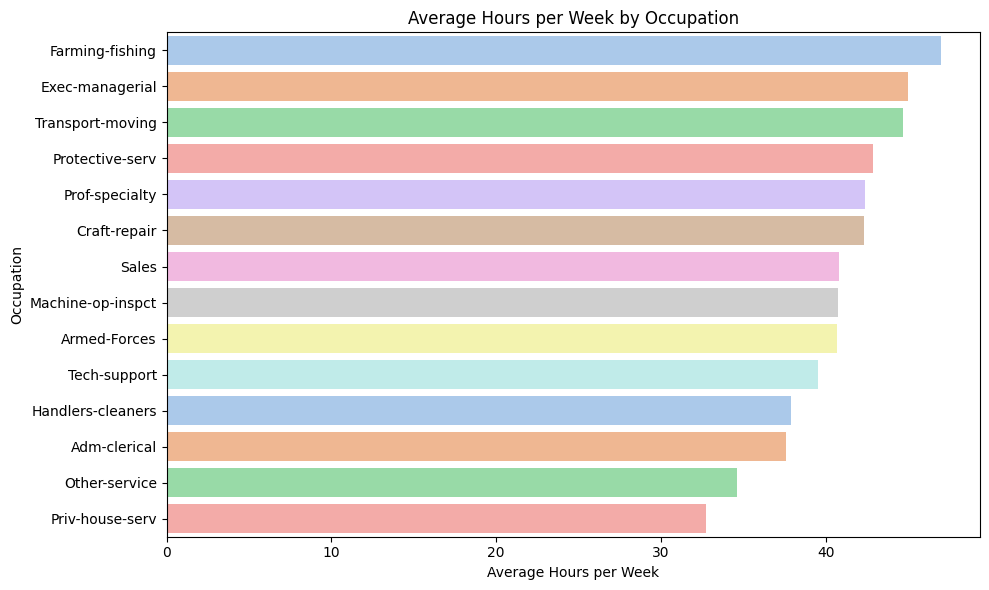

occupation
Farming-fishing      46.994934
Exec-managerial      44.970684
Transport-moving     44.650127
Protective-serv      42.846273
Prof-specialty       42.381011
Craft-repair         42.300870
Sales                40.763393
Machine-op-inspct    40.703666
Armed-Forces         40.666667
Tech-support         39.506037
Handlers-cleaners    37.862120
Adm-clerical         37.568163
Other-service        34.610159
Priv-house-serv      32.695035
Name: hours.per.week, dtype: float64


In [19]:
avg_hours_by_occ = df.groupby("occupation")["hours.per.week"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_hours_by_occ.values, y=avg_hours_by_occ.index, legend=False, palette="pastel")
plt.xlabel("Average Hours per Week")
plt.ylabel("Occupation")
plt.title("Average Hours per Week by Occupation")
plt.tight_layout()
plt.show()

print(avg_hours_by_occ)

Task 2

/tmp/ipykernel_647/1521347734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="education", data=df, order=order, legend=False, palette="pastel")


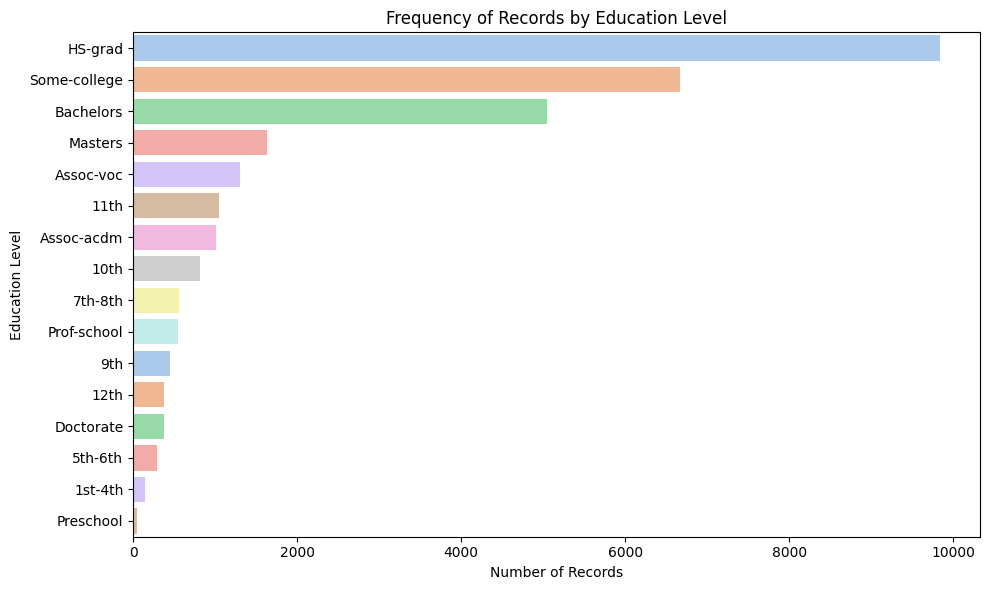

education
HS-grad         9834
Some-college    6669
Bachelors       5042
Masters         1626
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          556
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          287
1st-4th          149
Preschool         44
Name: count, dtype: int64

Most common category: HS-grad (9834 records)


In [20]:
plt.figure(figsize=(10, 6))
order = df["education"].value_counts().index
sns.countplot(y="education", data=df, order=order, legend=False, palette="pastel")
plt.xlabel("Number of Records")
plt.ylabel("Education Level")
plt.title("Frequency of Records by Education Level")
plt.tight_layout()
plt.show()

counts = df["education"].value_counts()
print(counts)
print(f"\nMost common category: {counts.idxmax()} ({counts.max()} records)")

Task 3

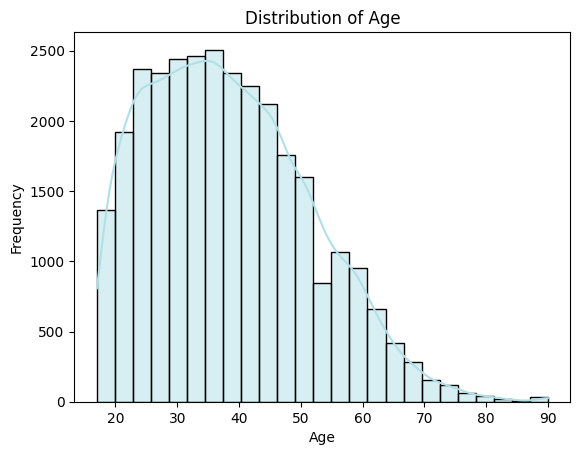

Skewness: 0.5289710877265393


In [17]:
plt.figure()
sns.histplot(df["age"], bins=25, kde=True, color="powderblue")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

skew = df["age"].skew()
print(f"Skewness: {skew:}")

In [23]:
print("since skew is positive 0.5, it means it is slightly right skewed.")

since skew is positive 0.5, it means it is slightly right skewed.


Task 4

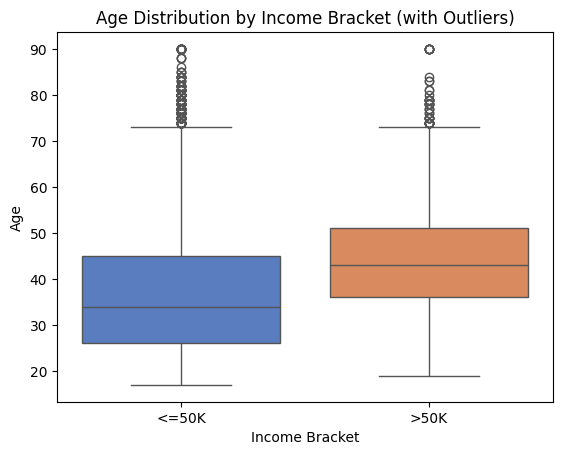

Points beyond the whiskers (visually/via same 1.5xIQR rule): 168


In [34]:
plt.figure()
sns.boxplot(x="income", y="age", data=df, hue="income", legend=False, palette="muted")
plt.xlabel("Income Bracket")
plt.ylabel("Age")
plt.title("Age Distribution by Income Bracket (with Outliers)")
plt.show()

# Count points plotted beyond the whiskers, using the same 1.5xIQR rule on the overall column
q1, q3 = df["age"].quantile([0.25, 0.75])
iqr_visual = q3 - q1
lower_w, upper_w = q1 - 1.5 * iqr_visual, q3 + 1.5 * iqr_visual
visual_outliers = df[(df["age"] < lower_w) | (df["age"] > upper_w)]
print(f"Points beyond the whiskers (visually/via same 1.5xIQR rule): {len(visual_outliers)}")

Task 5

In [29]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower bound={lower}, Upper bound={upper}")
print("IQR outlier count:", len(outliers))

Q1=28.0, Q3=47.0, IQR=19.0
Lower bound=-0.5, Upper bound=75.5
IQR outlier count: 168


Task 6

In [30]:
mean_age = df['age'].mean()
std_age = df['age'].std(ddof=0)

df['zscore'] = (df['age'] - mean_age) / std_age
outliers_z = df[df['zscore'].abs() > 3]
print("Z-score outlier count:", len(outliers_z))
print("IQR outlier count (from Task 5):", len(outliers))

Z-score outlier count: 119
IQR outlier count (from Task 5): 168


In [31]:
print("outlier count doesn't match\nmean is slightly pulled toward toward and std is inflated by the spread.\nzscore normal range is widened.")

outlier count doesn't match
mean is slightly pulled toward toward and std is inflated by the spread.
zscore normal range is widened.


Task 7

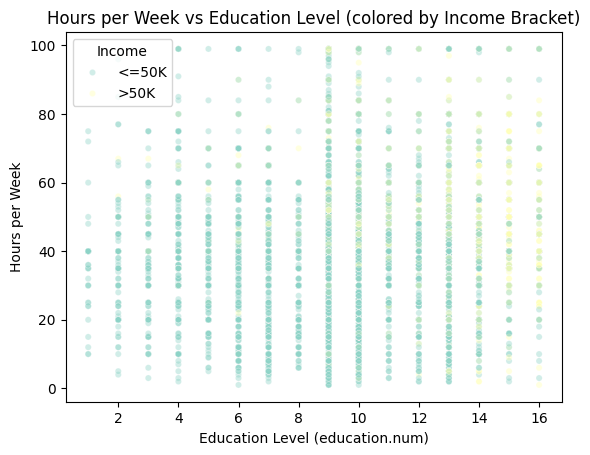

Correlation between education.num and hours.per.week: 0.153


In [44]:
plt.figure()
sns.scatterplot(x="education.num", y="hours.per.week", hue="income", data=df, palette="Set3", alpha=0.4, s=20)
plt.xlabel("Education Level (education.num)")
plt.ylabel("Hours per Week")
plt.title("Hours per Week vs Education Level (colored by Income Bracket)")
plt.legend(title="Income")
plt.show()

corr = df["education.num"].corr(df["hours.per.week"])
print(f"Correlation between education.num and hours.per.week: {corr:.3f}")

Task 8

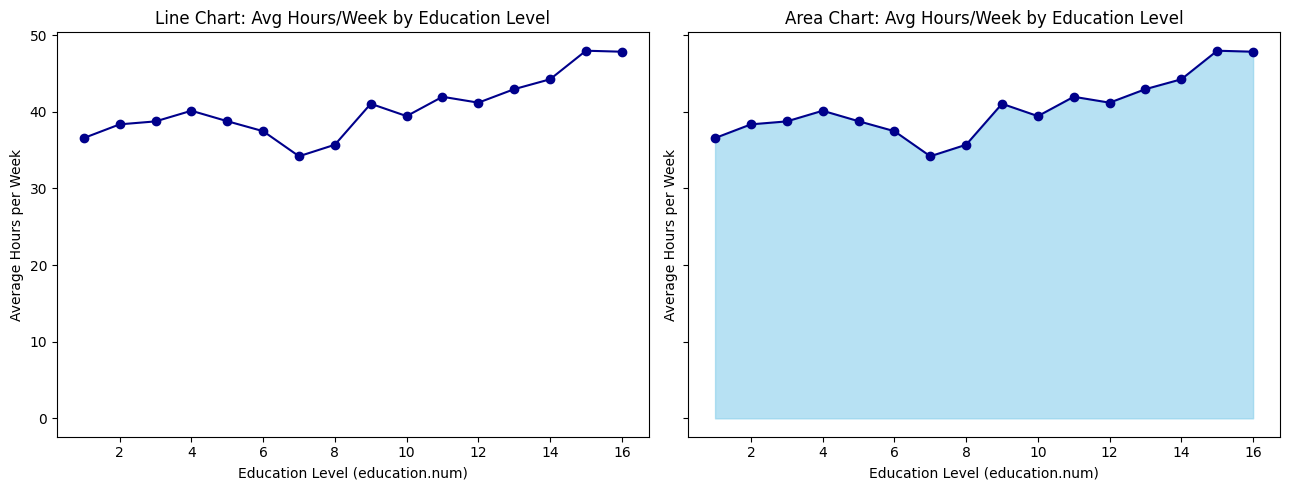

In [50]:
avg_hours_by_edu = df.groupby("education.num")["hours.per.week"].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker="o", color="darkblue")
axes[0].set_xlabel("Education Level (education.num)")
axes[0].set_ylabel("Average Hours per Week")
axes[0].set_title("Line Chart: Avg Hours/Week by Education Level")

axes[1].fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, color="skyblue", alpha=0.6)
axes[1].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker="o", color="darkblue")
axes[1].set_xlabel("Education Level (education.num)")
axes[1].set_ylabel("Average Hours per Week")
axes[1].set_title("Area Chart: Avg Hours/Week by Education Level")

plt.tight_layout()
plt.show()

Task 9

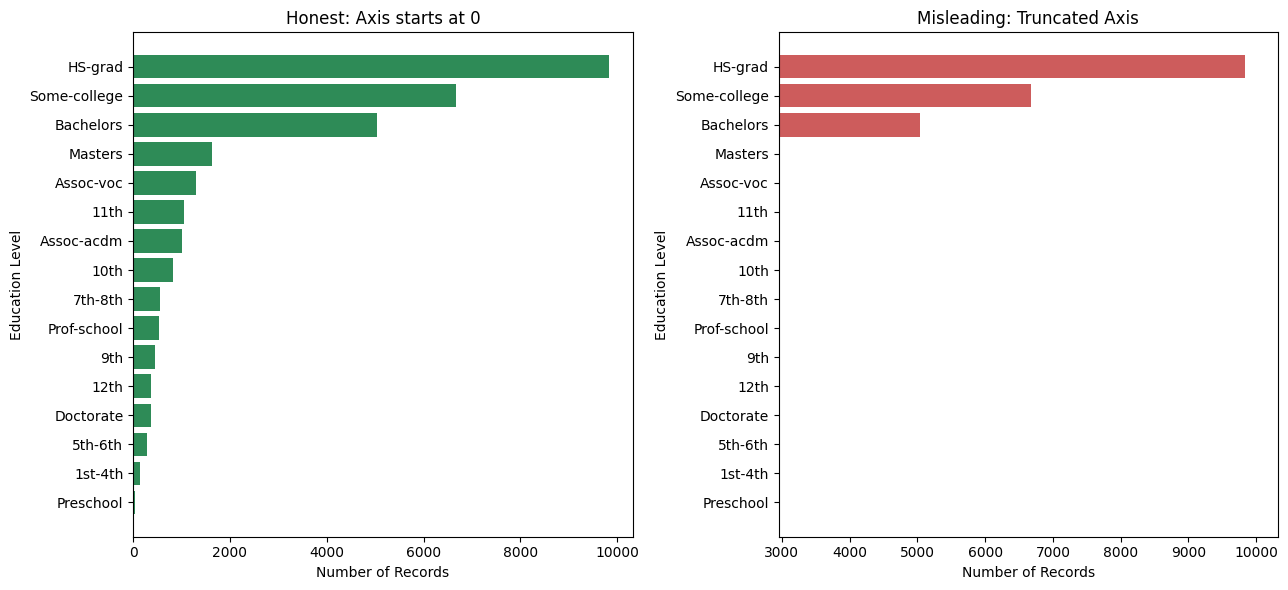

In [53]:
top_counts = df["education"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))


axes[0].barh(top_counts.index, top_counts.values, color="seagreen")
axes[0].set_xlim(left=0)
axes[0].set_xlabel("Number of Records")
axes[0].set_ylabel("Education Level")
axes[0].set_title("Honest: Axis starts at 0")
axes[0].invert_yaxis()


axes[1].barh(top_counts.index, top_counts.values, color="indianred")
axes[1].set_xlim(left=top_counts.max() * 0.3)
axes[1].set_xlabel("Number of Records")
axes[1].set_ylabel("Education Level")
axes[1].set_title("Misleading: Truncated Axis")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()